/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError
Spread cache:
  /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis-M3000/all_seeds_all_sigma_all_eff_analysis_cache
Isochrone cache:
  /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis-M3000/iso_cache

Loading cached isochrone  1.0 Myr
Loading cached isochrone  1.5 Myr
Loading cached isochrone  2.0 Myr
Loading cached isochrone  2.5 Myr
Loading cached isochrone  3.0 Myr
Loading cached isochrone  3.5 Myr
Loading cached isochrone  4.0 Myr
Loading cached isochrone  4.5 Myr
Loading cached isochrone  5.0 Myr
Loading cached isochrone  5.5 Myr
Loading cached isochrone  6.0 Myr


Loading cached isochrone  6.5 Myr
Loading cached isochrone  7.0 Myr
Loading cached isochrone  7.5 Myr
Loading cached isochrone  8.0 Myr
Loading cached isochrone  8.5 Myr
Loading cached isochrone  9.0 Myr
Loading cached isochrone  9.5 Myr
Loading cached isochrone 10.0 Myr
Loading cached isochrone 10.5 Myr
Loading cached isochrone 11.0 Myr
Loading cached isochrone 11.5 Myr
Loading cached isochrone 12.0 Myr
Loading cached isochrone 12.5 Myr


Loading cached isochrone 13.0 Myr
Loading cached isochrone 13.5 Myr
Loading cached isochrone 14.0 Myr
Loading cached isochrone 14.5 Myr
Loading cached isochrone 15.0 Myr
Loading cached isochrone 15.5 Myr
Loading cached isochrone 16.0 Myr
Loading cached isochrone 16.5 Myr
Loading cached isochrone 17.0 Myr
Loading cached isochrone 17.5 Myr
Loading cached isochrone 18.0 Myr
Loading cached isochrone 18.5 Myr
Loading cached isochrone 19.0 Myr


Loading cached isochrone 19.5 Myr
Loading cached isochrone 20.0 Myr

Interpolating ONLY seed 00 at 5 Myr


Retained 2329 cluster stars.

1 Myr 3000 K color = 3.744723
1 Myr 3600 K color = 2.392885

Reading cached spread-analysis results
Finite realization files: 100
Instantaneous files: 100


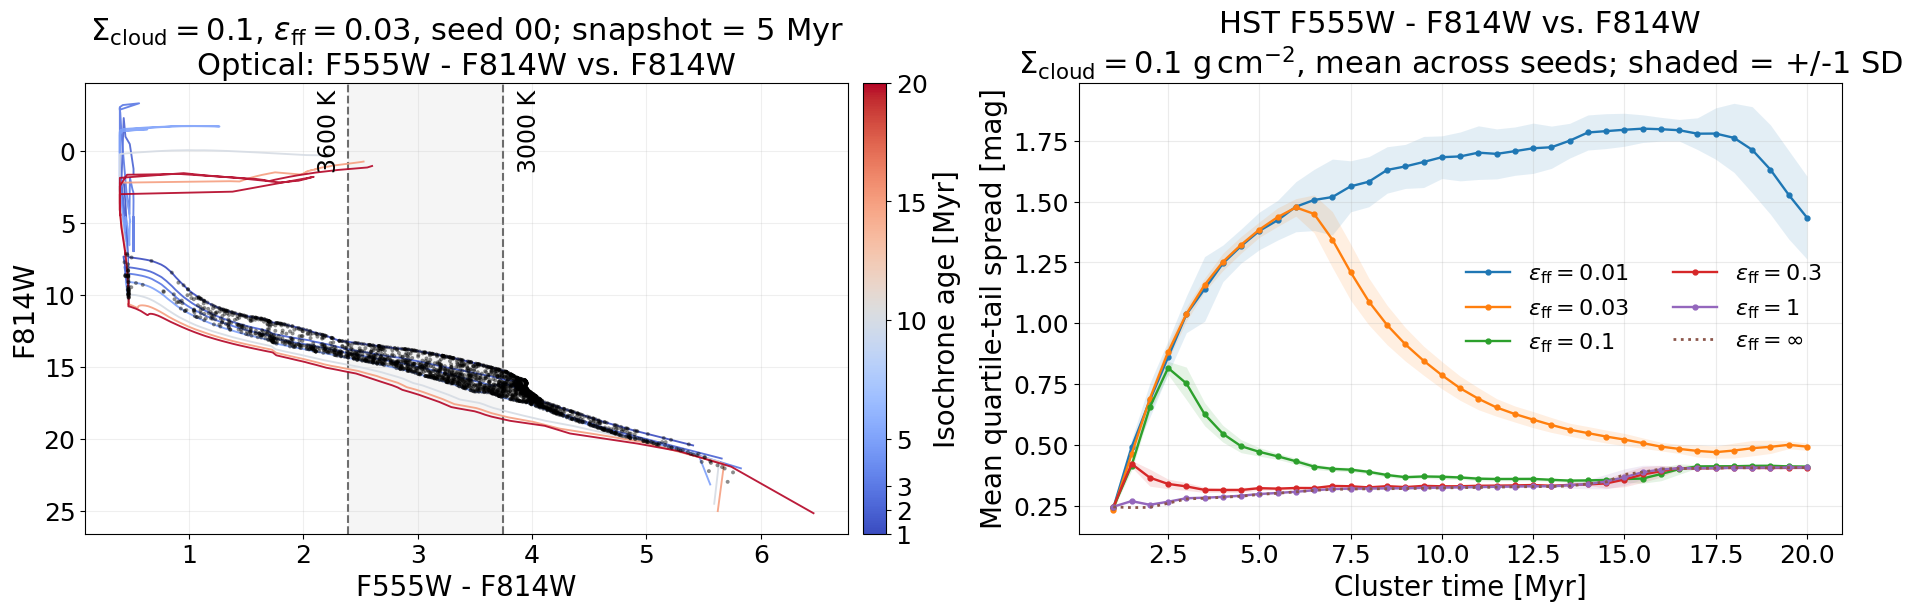


Done
Figure: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-12_full-analysis-M3000/hst_f555w_f814w_cmd_plus_cached_ensemble_large_font.png


In [1]:
# HST F555W-F814W composite figure using EXISTING spread-analysis cache
#
# LEFT:
#   Original HST CMD style
#   Sigma_cloud = 0.1
#   epsilon_ff = 0.03
#   seed 00
#   snapshot = 5 Myr
#   + fixed 1-Myr-derived 3000--3600 K color span
#
# RIGHT:
#   Reconstructed DIRECTLY FROM EXISTING SPREAD CACHE
#   original all-seed ensemble mean +/- 1 sample SD
#   original hierarchical epsilon_ff=infinity baseline
#
# No spread metric is recomputed.
# Only the single 5-Myr seed-00 CMD population is interpolated.


from __future__ import annotations

import contextlib
import io
import math
import os
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from astropy.table import Column, Table
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter


# =====================================================================
# SCRIPT-LOCAL PATHS
# =====================================================================

try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd().resolve()


# Existing spread-analysis cache.
CACHE_DIR = (
    SCRIPT_DIR
    / 'all_seeds_all_sigma_all_eff_analysis_cache'
)

# Existing SPISEA cache from the spread analysis.
ISO_CACHE_DIR = (
    SCRIPT_DIR
    / 'iso_cache'
)

OUTPUT_PATH = (
    SCRIPT_DIR
    / 'hst_f555w_f814w_cmd_plus_cached_ensemble_large_font.png'
)


# =====================================================================
# EXTERNAL SCIENTIFIC DATA PATHS
# =====================================================================

UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/'
    'baraffe_pisa_ekstrom_parsec/'
)

SIMULATION_PATH = Path(
    '/standard/Tan_JC/backup_protoclusters/multiples/M3000new/'
    'sigma0p1/fiducial/sfe_ff003/00'
)


# =====================================================================
# USE THE SAME INTERPOLATOR AS THE ORIGINAL ANALYSES
# =====================================================================

try:
    import interpolator

except ImportError:

    sys.path.append(
        '/home/wyz5rge/synthetic-cmd-dev/cmd_generator'
    )

    import interpolator


# =====================================================================
# CHECK REQUIRED INPUTS
# =====================================================================

if not CACHE_DIR.is_dir():
    raise FileNotFoundError(
        'Spread-analysis cache not found:\n'
        f'{CACHE_DIR}'
    )

if not ISO_CACHE_DIR.is_dir():
    raise FileNotFoundError(
        'Isochrone cache not found:\n'
        f'{ISO_CACHE_DIR}'
    )

if not UPDATED_MERGED_ROOT.is_dir():
    raise FileNotFoundError(
        'Merged evolution-model directory not found:\n'
        f'{UPDATED_MERGED_ROOT}'
    )

if not SIMULATION_PATH.is_dir():
    raise FileNotFoundError(
        'Seed-00 simulation not found:\n'
        f'{SIMULATION_PATH}'
    )


print('Spread cache:')
print(f'  {CACHE_DIR}')

print('Isochrone cache:')
print(f'  {ISO_CACHE_DIR}')

print()


# =====================================================================
# SCIENTIFIC CONFIGURATION
#
# Keep these identical to the original spread analysis.
# =====================================================================

PLOT_SIGMA = 0.1
PLOT_EFF = 0.03
PLOT_SEED = '00'
SNAPSHOT_TIME_MYR = 5.0

EFF_CONFIG = {
    0.01: 'sfe_ff001',
    0.03: 'sfe_ff003',
    0.10: 'sfe_ff010',
    0.30: 'sfe_ff030',
    1.00: 'sfe_ff100',
}

EFF_LABELS = {
    eff: rf'$\epsilon_{{\rm ff}}={eff:g}$'
    for eff in EFF_CONFIG
}


AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0

USE_ROTATING_MERGED = False

ATM_FUNC = (
    atmospheres.get_BTSettl_2015_atmosphere
)

RED_LAW = reddening.RedLawHosek18b()


ISO_AGES_MYR = np.arange(
    1.0,
    20.0 + 0.25,
    0.5,
)

ISO_LOG_AGES = np.log10(
    ISO_AGES_MYR * 1.0e6
)


# IMPORTANT:
# These are the exact seven ages used by the original HST plot.
PLOT_AGES_MYR = np.array([
    1.0,
    2.0,
    3.0,
    5.0,
    10.0,
    15.0,
    20.0,
])


TEFF_MIN_K = 3000.0
TEFF_MAX_K = 3600.0

CLIP_YOUNG_STARS_TO_GRID_MINIMUM = True


# =====================================================================
# FILTER CONFIGURATION
#
# Keep the SAME filter request used by the spread-analysis iso_cache.
#
# This maximizes compatibility with the already-saved SPISEA cache.
#
# BUT:
# the stellar interpolation below uses ONLY F555W and F814W.
# =====================================================================

FILTER_OBSMODES = {
    'F070W': 'jwst,F070W',
    'F182M': 'jwst,F182M',
    'F200W': 'jwst,F200W',
    'F555W': 'wfc3,uvis1,f555w',
    'F814W': 'wfc3,uvis1,f814w',
}

ALL_FILTERS = list(
    FILTER_OBSMODES.values()
)

HST_FILTER_NAMES = [
    'F555W',
    'F814W',
]


# =====================================================================
# ORIGINAL HST PLOT APPEARANCE
#
# Do not alter these line/point properties.
# =====================================================================

ISOCHRONE_CMAP_NAME = 'coolwarm'

ISOCHRONE_CMAP = plt.get_cmap(
    ISOCHRONE_CMAP_NAME
)

ISOCHRONE_NORM = Normalize(
    vmin=float(
        np.min(
            PLOT_AGES_MYR
        )
    ),
    vmax=float(
        np.max(
            PLOT_AGES_MYR
        )
    ),
)

ISOCHRONE_LINEWIDTH = 1.35
ISOCHRONE_ALPHA = 0.9

CLUSTER_MARKER_SIZE = 8
CLUSTER_ALPHA = 0.45
CLUSTER_COLOR = 'black'


# =====================================================================
# ONLY PRESENTATION CHANGE: LARGE FONT
# =====================================================================

FONT_SIZE = 20
TITLE_SIZE = 22
LABEL_SIZE = 20
TICK_SIZE = 18
LEGEND_SIZE = 16
COLORBAR_SIZE = 18
BAND_LABEL_SIZE = 17


# =====================================================================
# MERGED EVOLUTION-MODEL READER
# =====================================================================

class MergedBaraffePisaEkstromParsecDAT:

    def __init__(
        self,
        root_dir: Path | str,
        rot=False,
    ):
        self.root_dir = (
            Path(root_dir)
            .expanduser()
            .resolve()
        )

        self.rot = bool(rot)

        self.model_dir = str(
            self.root_dir
        )

        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []

        self.grid_dir = (
            self.root_dir
            / (
                'z015_rot'
                if rot
                else 'z015_norot'
            )
        )

        if not self.grid_dir.is_dir():
            raise FileNotFoundError(
                self.grid_dir
            )

        self.age_file_map = {}

        for path in sorted(
            self.grid_dir.glob(
                'iso_*.dat'
            )
        ):
            try:
                age = float(
                    path.stem.split('_')[1]
                )

            except (
                IndexError,
                ValueError,
            ):
                continue

            self.age_file_map[
                round(age, 2)
            ] = path

        if not self.age_file_map:
            raise FileNotFoundError(
                f'No iso_*.dat in '
                f'{self.grid_dir}'
            )

        self.age_list = np.array(
            sorted(
                self.age_file_map
            ),
            float,
        )


    def isochrone(
        self,
        age=1.0e6,
        metallicity=0.0,
    ):
        requested = math.log10(
            age
        )

        if (
            requested
            < self.age_list[0]
            or requested
            > self.age_list[-1]
        ):
            raise ValueError(
                f'logAge {requested:.4f} '
                'outside grid'
            )

        selected = float(
            self.age_list[
                np.argmin(
                    np.abs(
                        self.age_list
                        - requested
                    )
                )
            ]
        )

        path = self.age_file_map[
            round(
                selected,
                2,
            )
        ]

        dtype = [
            ('mass', 'f8'),
            ('logT', 'f8'),
            ('logL', 'f8'),
            ('logg', 'f8'),
            ('logT_WR', 'f8'),
            ('mass_current', 'f8'),
            ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]

        data = np.genfromtxt(
            path,
            comments='#',
            dtype=dtype,
            encoding='utf-8',
        )

        iso = Table(
            np.atleast_1d(
                data
            )
        )

        iso.add_column(
            Column(
                ~np.isclose(
                    np.asarray(
                        iso['logT'],
                        float,
                    ),
                    np.asarray(
                        iso['logT_WR'],
                        float,
                    ),
                    rtol=0.0,
                    atol=1.0e-8,
                ),
                name='isWR',
            )
        )

        iso.meta.update({
            'log_age': selected,
            'log_age_requested': requested,
            'metallicity_in': metallicity,
            'metallicity_act': 0.0,
            'source_file': str(path),
        })

        return iso


# =====================================================================
# ISOCHRONE HELPERS
# =====================================================================

@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    filter_columns: dict


def normalize_name(
    value,
):
    return ''.join(
        ch.lower()
        for ch in str(value)
        if ch.isalnum()
    )


def resolve_filter_column(
    colnames,
    filter_name,
):
    target = normalize_name(
        filter_name
    )

    candidates = [
        column
        for column in colnames
        if (
            normalize_name(
                column
            ).startswith('m')
            and normalize_name(
                column
            ).endswith(target)
        )
    ]

    instrument = (
        'hst'
        if filter_name
        in {
            'F555W',
            'F814W',
        }
        else 'jwst'
    )

    preferred = [
        column
        for column in candidates
        if instrument
        in normalize_name(
            column
        )
    ]

    if len(preferred) == 1:
        return preferred[0]

    if len(candidates) == 1:
        return candidates[0]

    raise KeyError(
        f'Could not resolve '
        f'{filter_name}; '
        f'candidates={candidates}'
    )


def build_iso_grid(
    evo_model,
):
    isochrones = []
    filter_columns = None

    for (
        age_myr,
        log_age,
    ) in zip(
        ISO_AGES_MYR,
        ISO_LOG_AGES,
    ):

        print(
            'Loading cached isochrone '
            f'{age_myr:4.1f} Myr'
        )

        iso = synthetic.IsochronePhot(
            log_age,
            AKS,
            DISTANCE_PC,
            metallicity=METALLICITY,
            evo_model=evo_model,
            atm_func=ATM_FUNC,
            red_law=RED_LAW,

            # Exact filter set used to generate the spread-analysis cache.
            filters=ALL_FILTERS,

            iso_dir=str(
                ISO_CACHE_DIR
            ),
        )

        current = {
            name: resolve_filter_column(
                iso.points.colnames,
                name,
            )
            for name
            in FILTER_OBSMODES
        }

        if filter_columns is None:
            filter_columns = current

        elif current != filter_columns:
            raise RuntimeError(
                'Magnitude-column names '
                'changed between isochrones.'
            )

        isochrones.append(
            iso
        )

    return IsoGrid(
        ages_myr=ISO_AGES_MYR.copy(),
        log_ages=ISO_LOG_AGES.copy(),
        isochrones=isochrones,
        filter_columns=filter_columns,
    )


# =====================================================================
# BUILD / LOAD EXISTING ISO CACHE
# =====================================================================

evo_model = (
    MergedBaraffePisaEkstromParsecDAT(
        UPDATED_MERGED_ROOT,
        rot=USE_ROTATING_MERGED,
    )
)

ISO_GRID = build_iso_grid(
    evo_model
)


# =====================================================================
# HST-ONLY INTERPOLATION
#
# Ignore the JWST columns entirely here.
# =====================================================================

HST_FILTER_KEYS = [
    ISO_GRID.filter_columns[
        name
    ]
    for name
    in HST_FILTER_NAMES
]


def safe_interpolate(
    age_myr,
    mass,
):
    try:

        with (
            warnings.catch_warnings(),
            contextlib.redirect_stdout(
                io.StringIO()
            ),
            contextlib.redirect_stderr(
                io.StringIO()
            ),
        ):
            warnings.simplefilter(
                'ignore'
            )

            result = (
                interpolator.interpolate(
                    age_myr,
                    mass,
                    ISO_GRID.isochrones,
                    ISO_GRID.log_ages,

                    # ONLY F555W and F814W.
                    HST_FILTER_KEYS,
                )
            )

        if result is None:
            return None

        result = np.asarray(
            result,
            float,
        )

        # L, Teff, logg, F555W, F814W
        if result.size != 5:
            return None

        if not np.all(
            np.isfinite(
                result
            )
        ):
            return None

        return result

    except Exception:
        return None


# =====================================================================
# ONE N-BODY SNAPSHOT ONLY
# =====================================================================

def load_cluster_table(
    sim_path,
    snapshot_time_myr,
):
    path = os.path.abspath(
        str(sim_path)
    )

    if not path.endswith('/'):
        path += '/'

    snapshot = Reader.read_snapshot(
        path,
        time=float(
            snapshot_time_myr
        ),
    )

    snapshot.to_physical()

    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore',
            message=(
                'divide by zero '
                'encountered in log10'
            ),
            category=RuntimeWarning,
        )

        table = (
            converter.to_spicea_table(
                snapshot
            )
        )

    return table


def interpolate_hst_snapshot(
    table,
):
    masses = np.asarray(
        table['mass'],
        float,
    )

    ages = np.asarray(
        table['age'],
        float,
    )

    age_min = float(
        ISO_GRID.ages_myr.min()
    )

    age_max = float(
        ISO_GRID.ages_myr.max()
    )

    rows = []

    for mass, age in zip(
        masses,
        ages,
    ):
        mass = float(
            mass
        )

        age = float(
            age
        )

        if not np.isfinite(
            mass
        ):
            continue

        if not np.isfinite(
            age
        ):
            continue

        used_age = age

        if used_age < age_min:

            if (
                CLIP_YOUNG_STARS_TO_GRID_MINIMUM
            ):
                used_age = age_min

            else:
                continue

        if used_age > age_max:
            continue


        result = safe_interpolate(
            used_age,
            mass,
        )

        if result is None:
            continue


        luminosity = float(
            result[0]
        )

        teff = float(
            result[1]
        )

        logg = float(
            result[2]
        )

        mag_f555w = float(
            result[3]
        )

        mag_f814w = float(
            result[4]
        )


        rows.append({
            'mass': mass,
            'age_myr': age,
            'age_used_myr': used_age,
            'teff': teff,
            'luminosity_watts': luminosity,
            'logg': logg,
            'mag_F555W': mag_f555w,
            'mag_F814W': mag_f814w,
        })


    return pd.DataFrame(
        rows
    )


print()
print('=' * 72)
print('Interpolating ONLY seed 00 at 5 Myr')
print('=' * 72)

cluster_table = load_cluster_table(
    SIMULATION_PATH,
    SNAPSHOT_TIME_MYR,
)

df_cluster = interpolate_hst_snapshot(
    cluster_table
)

if df_cluster.empty:
    raise RuntimeError(
        'No stars survived the '
        '5 Myr HST interpolation.'
    )

print(
    f'Retained {len(df_cluster)} '
    f'cluster stars.'
)


# =====================================================================
# ORIGINAL HST CMD HELPERS
# =====================================================================

def get_iso_cmd(
    iso,
):
    blue = np.asarray(
        iso.points[
            ISO_GRID.filter_columns[
                'F555W'
            ]
        ],
        float,
    )

    red = np.asarray(
        iso.points[
            ISO_GRID.filter_columns[
                'F814W'
            ]
        ],
        float,
    )

    y = np.asarray(
        iso.points[
            ISO_GRID.filter_columns[
                'F814W'
            ]
        ],
        float,
    )

    color = (
        blue
        - red
    )

    good = (
        np.isfinite(
            color
        )
        & np.isfinite(
            y
        )
    )

    return (
        color[
            good
        ],
        y[
            good
        ],
    )


def get_cluster_cmd(
    df,
):
    color = (
        df[
            'mag_F555W'
        ].to_numpy(float)
        - df[
            'mag_F814W'
        ].to_numpy(float)
    )

    y = df[
        'mag_F814W'
    ].to_numpy(float)

    good = (
        np.isfinite(
            color
        )
        & np.isfinite(
            y
        )
    )

    return (
        color[
            good
        ],
        y[
            good
        ],
    )


# =====================================================================
# EXACT 1-MYR 3000 / 3600 K COLOR BOUNDARIES
#
# Same interpolation logic used by the spread analysis.
# =====================================================================

def interpolate_color_at_teff(
    iso,
    target,
    half_width=250.0,
):

    teff = np.asarray(
        iso.points[
            'Teff'
        ],
        float,
    )

    blue = np.asarray(
        iso.points[
            ISO_GRID.filter_columns[
                'F555W'
            ]
        ],
        float,
    )

    red = np.asarray(
        iso.points[
            ISO_GRID.filter_columns[
                'F814W'
            ]
        ],
        float,
    )

    color = (
        blue
        - red
    )

    good = (
        np.isfinite(
            color
        )
        & np.isfinite(
            teff
        )
        & (
            teff
            >= target
            - half_width
        )
        & (
            teff
            <= target
            + half_width
        )
    )

    t = teff[
        good
    ]

    c = color[
        good
    ]

    if len(t) < 2:
        raise RuntimeError(
            f'Not enough points '
            f'near {target:g} K.'
        )

    order = np.argsort(
        t
    )

    t = t[
        order
    ]

    c = c[
        order
    ]

    unique_t, inverse = np.unique(
        t,
        return_inverse=True,
    )

    sums = np.zeros_like(
        unique_t
    )

    counts = np.zeros_like(
        unique_t
    )

    np.add.at(
        sums,
        inverse,
        c,
    )

    np.add.at(
        counts,
        inverse,
        1,
    )

    unique_c = (
        sums
        / counts
    )

    return float(
        np.interp(
            target,
            unique_t,
            unique_c,
        )
    )


reference_idx = int(
    np.argmin(
        np.abs(
            ISO_GRID.ages_myr
            - 1.0
        )
    )
)

reference_iso = (
    ISO_GRID.isochrones[
        reference_idx
    ]
)


x_3000 = (
    interpolate_color_at_teff(
        reference_iso,
        3000.0,
    )
)

x_3600 = (
    interpolate_color_at_teff(
        reference_iso,
        3600.0,
    )
)


x_band_low = min(
    x_3000,
    x_3600,
)

x_band_high = max(
    x_3000,
    x_3600,
)


print()
print(
    f'1 Myr 3000 K color = '
    f'{x_3000:.6f}'
)

print(
    f'1 Myr 3600 K color = '
    f'{x_3600:.6f}'
)


# =====================================================================
# LOAD ORIGINAL SPREAD RESULTS DIRECTLY FROM CACHE
# =====================================================================

SIGMA_CACHE_DIR = (
    CACHE_DIR
    / 'sigma_0p1'
)

if not SIGMA_CACHE_DIR.is_dir():
    raise FileNotFoundError(
        'Expected Sigma=0.1 cache '
        'directory not found:\n'
        f'{SIGMA_CACHE_DIR}'
    )


finite_files = sorted(
    SIGMA_CACHE_DIR.glob(
        'eff_*/seed_*/finite_summary.csv'
    )
)

inst_files = sorted(
    SIGMA_CACHE_DIR.glob(
        'eff_*/seed_*/instantaneous_summary.csv'
    )
)


if not finite_files:
    raise RuntimeError(
        'No finite_summary.csv files '
        'found in the spread cache.'
    )

if not inst_files:
    raise RuntimeError(
        'No instantaneous_summary.csv '
        'files found in the spread cache.'
    )


print()
print('=' * 72)
print('Reading cached spread-analysis results')
print('=' * 72)

print(
    f'Finite realization files: '
    f'{len(finite_files)}'
)

print(
    f'Instantaneous files: '
    f'{len(inst_files)}'
)


finite = pd.concat(
    [
        pd.read_csv(
            path,
            dtype={
                'seed': str
            },
        )
        for path
        in finite_files
    ],
    ignore_index=True,
)

inst = pd.concat(
    [
        pd.read_csv(
            path,
            dtype={
                'seed': str
            },
        )
        for path
        in inst_files
    ],
    ignore_index=True,
)


# We care ONLY about this HST diagram.
finite = finite[
    finite[
        'diagram'
    ]
    == 'hst_f555w_f814w'
].copy()

inst = inst[
    inst[
        'diagram'
    ]
    == 'hst_f555w_f814w'
].copy()


if finite.empty:
    raise RuntimeError(
        'No cached finite '
        'hst_f555w_f814w results.'
    )

if inst.empty:
    raise RuntimeError(
        'No cached instantaneous '
        'hst_f555w_f814w results.'
    )


# =====================================================================
# ORIGINAL ENSEMBLE STATISTICS
# =====================================================================

def ensemble_stats(
    df,
    groups,
    value='spread_metric',
):

    def one(
        group,
    ):
        values = pd.to_numeric(
            group[
                value
            ],
            errors='coerce',
        ).to_numpy(float)

        values = values[
            np.isfinite(
                values
            )
        ]

        n = len(
            values
        )

        if not n:
            return pd.Series({
                'n_contributing': 0,
                'mean': np.nan,
                'std': np.nan,
            })

        std = (
            float(
                np.std(
                    values,
                    ddof=1,
                )
            )
            if n > 1
            else np.nan
        )

        return pd.Series({
            'n_contributing': n,
            'mean': float(
                np.mean(
                    values
                )
            ),
            'std': std,
        })


    return (
        df.groupby(
            groups,
            dropna=False,
        )
        .apply(
            one
        )
        .reset_index()
    )


# ---------------------------------------------------------------------
# Finite ensemble:
# SAME grouping as original analysis.
# ---------------------------------------------------------------------

finite_ens = (
    ensemble_stats(
        finite,
        [
            'sigma_cloud_g_cm2',
            'source_epsilon_ff',
            'diagram',
            'diagram_title',
            'snapshot_time_myr',
        ],
    )
    .rename(
        columns={
            'source_epsilon_ff':
                'epsilon_ff'
        }
    )
)


# ---------------------------------------------------------------------
# Instantaneous:
#
# 1. seed mean within source-epsilon_ff
# 2. equal-weight mean across source-epsilon_ff families
#
# SAME as original analysis.
# ---------------------------------------------------------------------

inst_by_source = (
    ensemble_stats(
        inst,
        [
            'sigma_cloud_g_cm2',
            'source_epsilon_ff',
            'diagram',
            'diagram_title',
            'snapshot_time_myr',
        ],
    )
)


inst_family_means = (
    inst_by_source[
        [
            'sigma_cloud_g_cm2',
            'source_epsilon_ff',
            'diagram',
            'diagram_title',
            'snapshot_time_myr',
            'mean',
        ]
    ]
    .rename(
        columns={
            'mean':
                'source_family_mean'
        }
    )
)


inst_sigma = (
    ensemble_stats(
        inst_family_means,
        [
            'sigma_cloud_g_cm2',
            'diagram',
            'diagram_title',
            'snapshot_time_myr',
        ],
        value='source_family_mean',
    )
)


# =====================================================================
# FINAL FIGURE
# =====================================================================

font_settings = {
    'font.size': FONT_SIZE,
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': LEGEND_SIZE,
}


with plt.rc_context(
    font_settings
):

    fig, (
        ax_cmd,
        ax_spread,
    ) = plt.subplots(
        1,
        2,

        # Roughly two original 9.2x6 spread panels side by side.
        figsize=(
            18.4,
            6.0,
        ),

        constrained_layout=True,
    )


    # ==============================================================
    # LEFT: ORIGINAL HST CMD STYLE
    # ==============================================================

    # Added measurement-band visualization.
    ax_cmd.axvspan(
        x_band_low,
        x_band_high,
        color='0.5',
        alpha=0.08,
        zorder=0,
    )


    ax_cmd.axvline(
        x_3600,
        color='0.25',
        linestyle='--',
        linewidth=1.5,
        alpha=0.75,
        zorder=1,
    )


    ax_cmd.axvline(
        x_3000,
        color='0.25',
        linestyle='--',
        linewidth=1.5,
        alpha=0.75,
        zorder=1,
    )


    # --------------------------------------------------------------
    # EXACT original HST plotting ages:
    # 1, 2, 3, 5, 10, 15, 20 Myr.
    #
    # No extra scatter is drawn on the isochrones.
    # --------------------------------------------------------------

    for requested_age_myr in PLOT_AGES_MYR:

        idx = int(
            np.argmin(
                np.abs(
                    ISO_GRID.ages_myr
                    - requested_age_myr
                )
            )
        )

        iso = (
            ISO_GRID.isochrones[
                idx
            ]
        )

        actual_age_myr = float(
            ISO_GRID.ages_myr[
                idx
            ]
        )

        color, y_mag = (
            get_iso_cmd(
                iso
            )
        )


        ax_cmd.plot(
            color,
            y_mag,
            color=ISOCHRONE_CMAP(
                ISOCHRONE_NORM(
                    actual_age_myr
                )
            ),
            linewidth=(
                ISOCHRONE_LINEWIDTH
            ),
            alpha=(
                ISOCHRONE_ALPHA
            ),
            zorder=2,
        )


    # Original cluster style.
    cluster_color, cluster_y = (
        get_cluster_cmd(
            df_cluster
        )
    )


    ax_cmd.scatter(
        cluster_color,
        cluster_y,
        s=CLUSTER_MARKER_SIZE,
        alpha=CLUSTER_ALPHA,
        color=CLUSTER_COLOR,
        edgecolors='none',
        zorder=5,
    )


    # --------------------------------------------------------------
    # Temperature-boundary labels.
    #
    # 3600 K intentionally gets extra space from its line.
    # --------------------------------------------------------------

    ax_cmd.annotate(
        '3600 K',
        xy=(
            x_3600,
            0.985,
        ),
        xycoords=(
            'data',
            'axes fraction',
        ),
        xytext=(
            -5,
            0,
        ),
        textcoords='offset points',
        rotation=90,
        ha='right',
        va='top',
        fontsize=BAND_LABEL_SIZE,
    )


    ax_cmd.annotate(
        '3000 K',
        xy=(
            x_3000,
            0.985,
        ),
        xycoords=(
            'data',
            'axes fraction',
        ),
        xytext=(
            10,
            0,
        ),
        textcoords='offset points',
        rotation=90,
        ha='left',
        va='top',
        fontsize=BAND_LABEL_SIZE,
    )


    ax_cmd.set_xlabel(
        'F555W - F814W'
    )

    ax_cmd.set_ylabel(
        'F814W'
    )


    ax_cmd.set_title(
        r'$\Sigma_{\rm cloud}=0.1$, '
        r'$\epsilon_{\rm ff}=0.03$, '
        'seed 00; snapshot = 5 Myr\n'
        'Optical: F555W - F814W vs. F814W'
    )


    ax_cmd.invert_yaxis()

    ax_cmd.grid(
        alpha=0.2
    )


    # No legend inside CMD.


    # Original age colorbar.
    age_mappable = (
        ScalarMappable(
            norm=ISOCHRONE_NORM,
            cmap=ISOCHRONE_CMAP,
        )
    )

    age_mappable.set_array(
        PLOT_AGES_MYR
    )


    cbar = fig.colorbar(
        age_mappable,
        ax=ax_cmd,
        orientation='vertical',
        pad=0.02,
    )


    cbar.set_label(
        'Isochrone age [Myr]',
        fontsize=LABEL_SIZE,
    )

    cbar.set_ticks(
        PLOT_AGES_MYR
    )

    cbar.ax.tick_params(
        labelsize=COLORBAR_SIZE
    )


    # ==============================================================
    # RIGHT: EXACT ORIGINAL CACHED ENSEMBLE PLOT
    # ==============================================================

    for eff in EFF_CONFIG:

        sub = (
            finite_ens[
                (
                    finite_ens[
                        'sigma_cloud_g_cm2'
                    ]
                    == PLOT_SIGMA
                )
                & (
                    finite_ens[
                        'epsilon_ff'
                    ]
                    == eff
                )
                & (
                    finite_ens[
                        'diagram'
                    ]
                    == 'hst_f555w_f814w'
                )
            ]
            .sort_values(
                'snapshot_time_myr'
            )
        )


        if sub.empty:
            continue


        # EXACT original line properties.
        line = ax_spread.plot(
            sub[
                'snapshot_time_myr'
            ],
            sub[
                'mean'
            ],
            marker='o',
            ms=3.5,
            lw=1.7,
            label=EFF_LABELS[
                eff
            ],
        )[0]


        # EXACT original +/-1 SAMPLE SD shading.
        valid = (
            np.isfinite(
                sub[
                    'mean'
                ]
            )
            & np.isfinite(
                sub[
                    'std'
                ]
            )
        )


        lower = (
            sub.loc[
                valid,
                'mean'
            ]
            - sub.loc[
                valid,
                'std'
            ]
        )


        upper = (
            sub.loc[
                valid,
                'mean'
            ]
            + sub.loc[
                valid,
                'std'
            ]
        )


        ax_spread.fill_between(
            sub.loc[
                valid,
                'snapshot_time_myr'
            ],
            lower,
            upper,
            alpha=0.12,
            color=line.get_color(),
            linewidth=0,
        )


    # Original hierarchical instantaneous baseline.
    base = (
        inst_sigma[
            (
                inst_sigma[
                    'sigma_cloud_g_cm2'
                ]
                == PLOT_SIGMA
            )
            & (
                inst_sigma[
                    'diagram'
                ]
                == 'hst_f555w_f814w'
            )
        ]
        .sort_values(
            'snapshot_time_myr'
        )
    )


    if not base.empty:

        ax_spread.plot(
            base[
                'snapshot_time_myr'
            ],
            base[
                'mean'
            ],
            lw=2.0,
            ls=':',
            label=(
                r'$\epsilon_{\rm ff}'
                r'=\infty$'
            ),
        )


    ax_spread.set_xlabel(
        'Cluster time [Myr]'
    )


    ax_spread.set_ylabel(
        'Mean quartile-tail spread [mag]'
    )


    ax_spread.set_title(
        'HST F555W - F814W vs. F814W\n'
        r'$\Sigma_{\rm cloud}=0.1\ '
        r'{\rm g\,cm^{-2}}$'
        ', mean across seeds; '
        'shaded = +/-1 SD'
    )


    ax_spread.grid(
        alpha=0.25
    )


    ax_spread.legend(
        frameon=False,
        ncol=2,
    )


    # ==============================================================
    # SAVE / SHOW
    # ==============================================================

    fig.savefig(
        OUTPUT_PATH,
        dpi=220,
        bbox_inches='tight',
    )

    plt.show()


print()
print('=' * 72)
print('Done')
print('=' * 72)

print(
    'Figure:',
    OUTPUT_PATH.resolve(),
)